# Overall Design

## C4 Container Diagram for LLM Inference Platform Architecture.


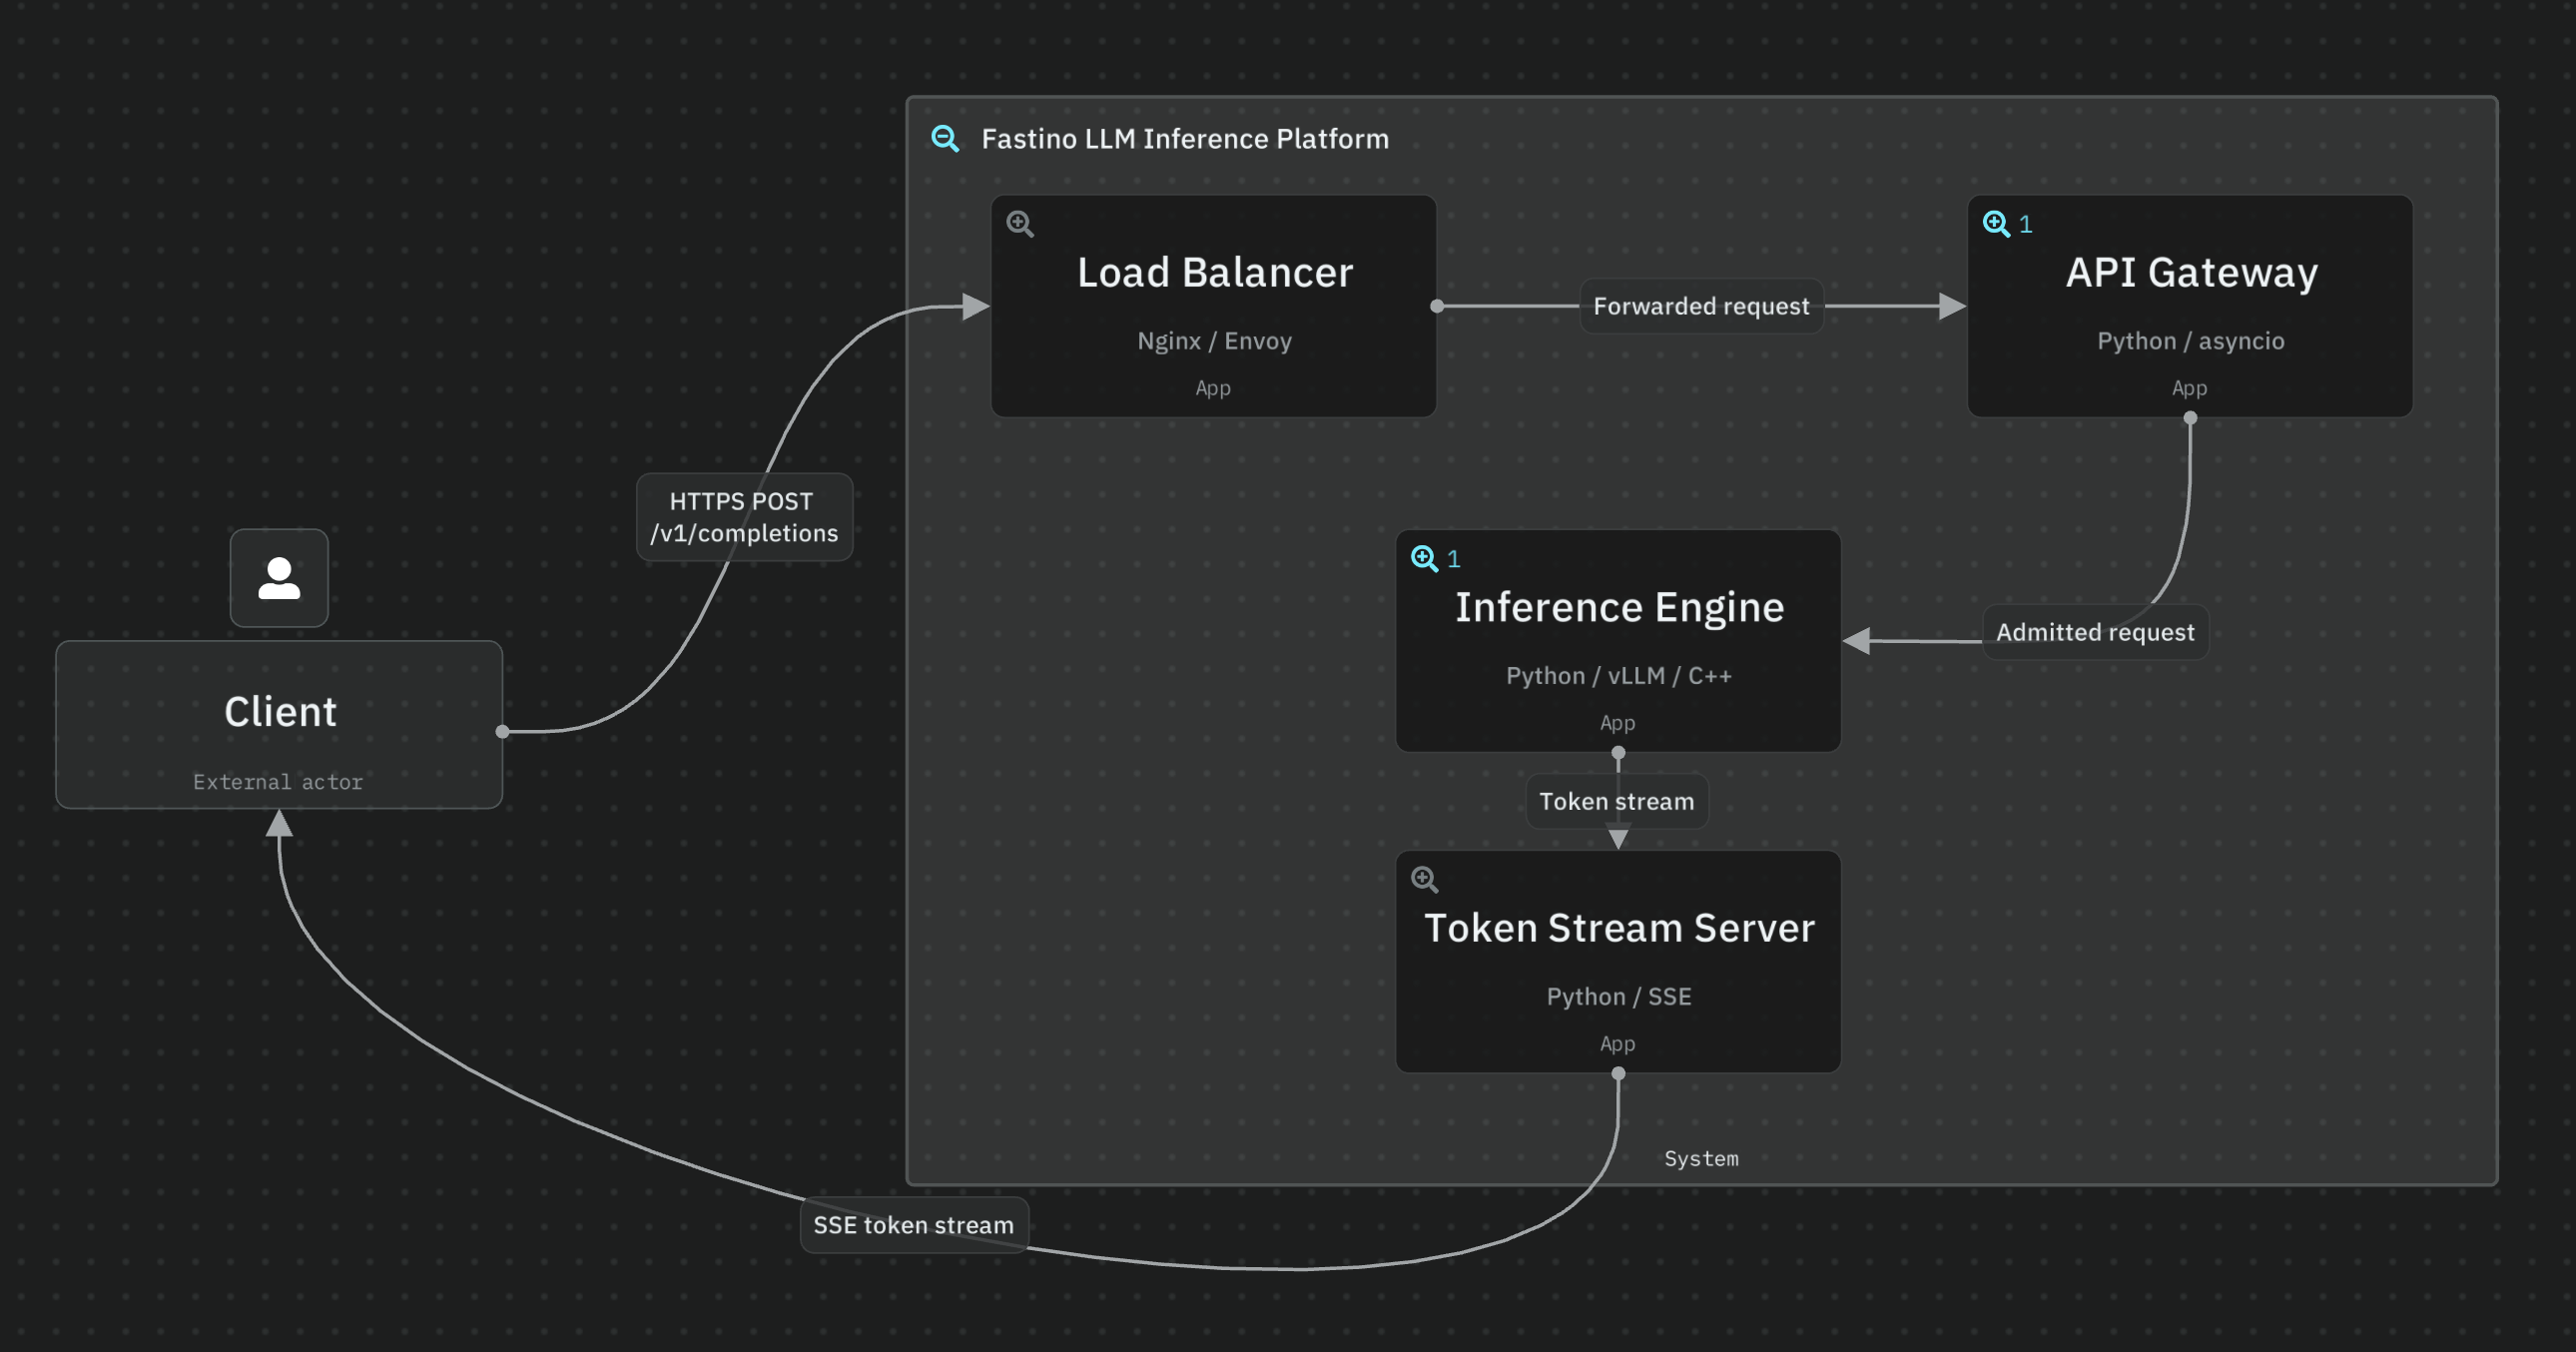

Link to diagram on icepanel.io: https://s.icepanel.io/X7127RWouBNohc/BKOL

Github - mock code to refer: https://github.com/udaymanhas9/LLM-Inference-System-Design

### Request flow
1. Ingress: Client sends HTTPS POST /v1/completions. Load Balancer (Nginx) routes traffic

2. Admission: API Gateway (Python/asyncio) validates request, handles multi-tenant auth, and enforces rate limits. Forwards to Inference Engine

3. Generation: Inference Engine (vLLM/C++/JAX) batches request. Allocates GPU memory. Generates tokens iteratively.

4. Internal Stream: Engine pipes generated tokens to Token Stream Server

5. Egress: Token Stream Server establishes Server-Sent Events (SSE) connection. Streams tokens back to Client in real-time

Specs for model:
- Model size: ~13B parameters
- Average prompt length: 500 tokens
- Average response length: 200 tokens
- Target traffic: 5,000 requests per second
- Latency target: P95 < 2 seconds
- Infrastructure: GPU-based
- Streaming: Users receive tokens as they are generated (token streaming required)

#Load Balancer


### Proxy Comparison Table

$$
\begin{array}{|l|l|l|l|l|}
\hline
\textbf{Proxy} & \textbf{Architecture} & \textbf{Streaming (SSE)} & \textbf{Use Case} & \textbf{Verdict} \\
\hline
\text{Apache} & \text{Thread-per-connection} & \text{Poor} & \text{Legacy web hosting} & \text{Reject: High memory overhead} \\
\hline
\text{Nginx} & \text{Event-driven} & \text{Good} & \text{Standard HTTP traffic} & \text{Viable: Lacks advanced routing} \\
\hline
\text{Envoy} & \text{Event-driven, Cloud-native} & \text{Excellent} & \text{High-concurrency APIs} & \text{Select: Best for burst mgmt} \\
\hline
\end{array}
$$

Component: Envoy (Upgraded from Nginx for state of the art streaming support)

Scalability: Asynchronous. Natively absorbs 5,000 RPS bursts

Latency: C++ core. Connection pooling cuts HTTP handshake overhead. Essential for P95 < 2s

Infrastructure Constraints: It can run on cheap CPUs. Offloads SSL and connection state to strictly reserve  GPUs for 13B model inference.

Specs Match: Optimised for massive concurrent, long lived SSE connections without head of line blocking.

# Admission: API Gateway






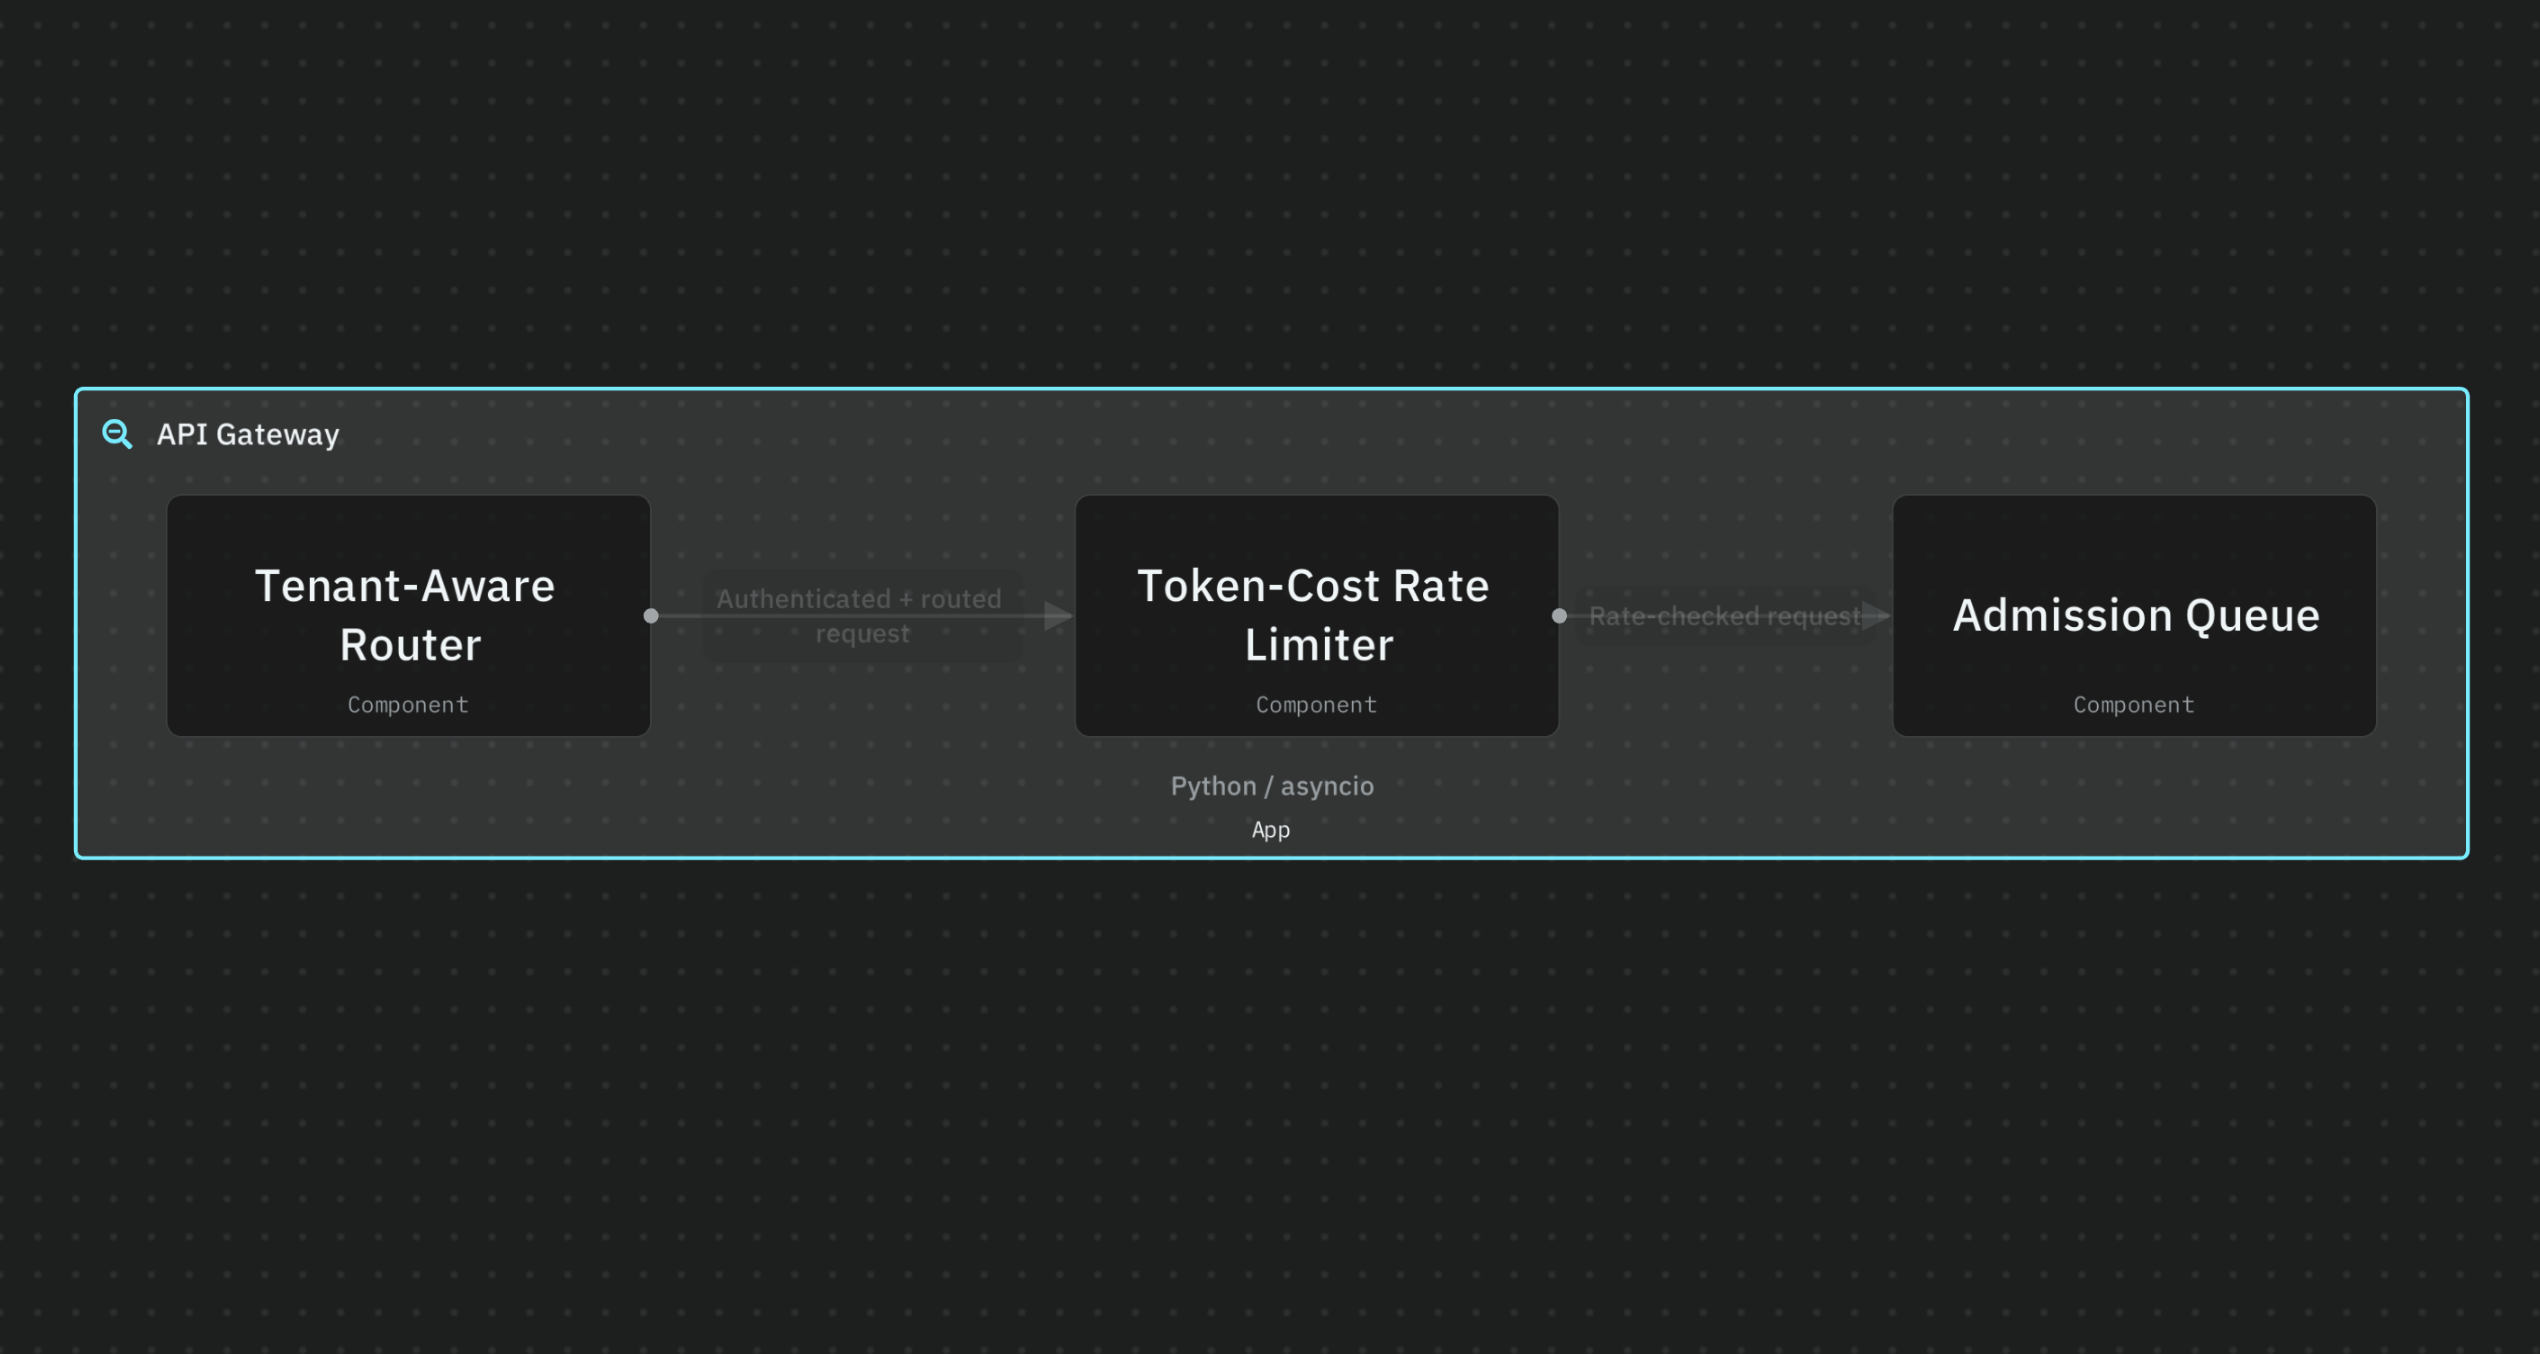


Component: Python asyncio.PriorityQueue (In-process).

Why this: Decouples ingress rate from inference capacity. Rejected Kafka/Redis to avoid 2–10ms P99 network latency per hop. Message durability unnecessary.

Scalability:
- Absorbs sudden traffic bursts; protects downstream GPU workers from crashing.
- Returns 429 (Retry-After) only on sustained bursts when queue fills.
- Handles multi-tenancy: Higher tiers preempt queue position.

Latency:
- In-memory execution eliminates database network hops.
- Budgets ~500ms for P95 queue wait time. Leaves 1.5s for generation to comfortably hit the P95 < 2s target.

Infrastructure Constraints:
- Ephemeral state (memory-only).
- Pod restarts drop queue and return 503s to trigger client retries.
- Eliminates need to manage heavy message brokers.

Specs Match:
- Buffering 5,000 requests per second fits easily in standard process memory.
- With 700 total tokens per request, GPU compute is the hard bottleneck. Admission must remain lightweight and local to prevent inflating latency.

# Generation: Inference Engine

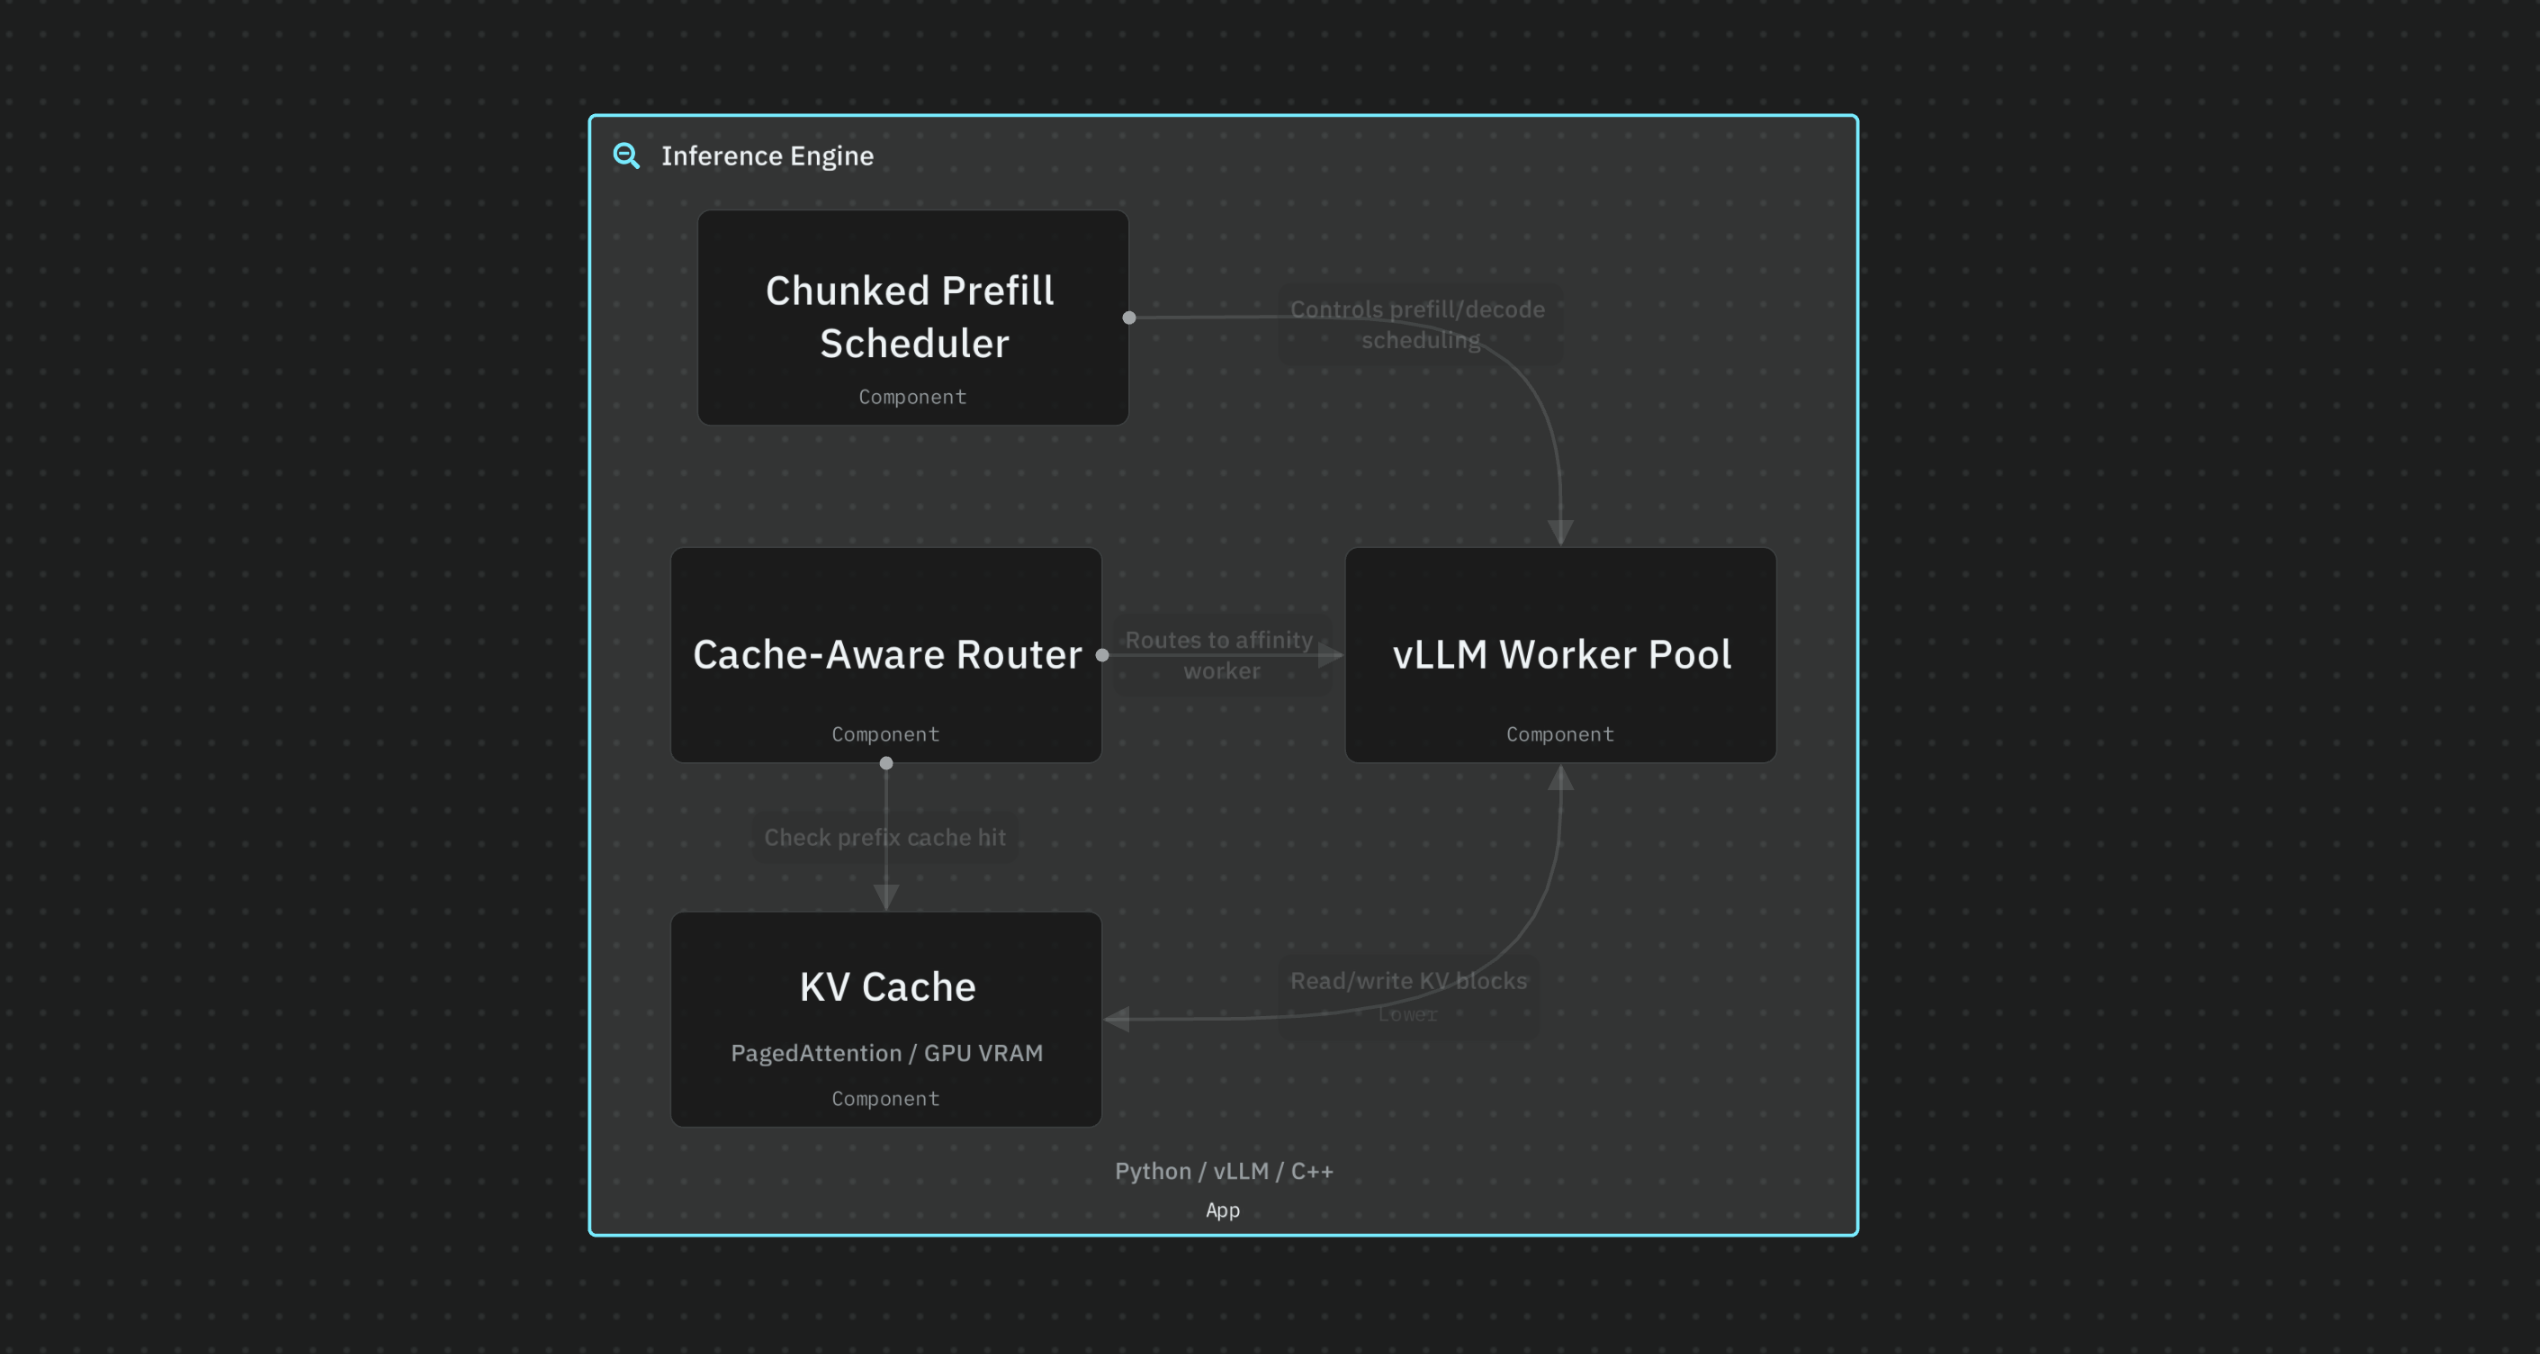

Component: vLLM (Python with C++ CUDA kernels)

Why this: Best open-source implementation of PagedAttention and continuous batching. Chosen over TensorRT-LLM to avoid NVIDIA toolchain lock-in and model recompilations. C++ Kernels allow direct, mutable memory control for KV caching.

Scalability:
- Continuous Batching: Injects requests per step. Zero GPU idle time.
- PagedAttention: Virtual memory pages for KV cache. Zero fragmentation. Enables prefix sharing (copy on write)

Latency:
- Chunked Prefill: Caps prefill compute per iteration. Prevents 500-token prompts from stalling active decodes.
- Result: Drops decode latency. Total request lifecycle ~635ms (safely meets P95 < 2s)

Infrastructure Specs:
- Need 8-10 H100 GPUs for 5000 RPS
- 13B fp16 = 26GB weights. Leaves ~50GB VRAM for KV cache per GPU
- 700 tokens (500 prompt + 200 response) = ~560MB KV cache per request
- Supports ~80 concurrent requests per H100

### System and Model Parameters

#### Hardware Specs (NVIDIA H100 SXM5)
* Total VRAM: $V_{\text{total}} = 80\text{ GB HBM3}$
* Memory Bandwidth: $\text{BW}_{\text{mem}} = 3.35\text{ TB/s}$
* Thermal Design Power: $\text{TDP} = 700\text{ W}$

#### Inference Throughput
* Decode Throughput: $\theta_{\text{decode}} \approx 4,000\text{ tok/s}$ (Memory-bandwidth bound)
* Prefill Throughput: $\theta_{\text{prefill}} \approx 20,000\text{ tok/s}$ (Compute-bound)

Decode is memory-bandwidth bound. The theoretical ceiling at batch=64 on H100 is $\frac{64 \times 3.35\ \text{TB/s}}{26\ \text{GB}} \approx 8,000$ tok/s. We use 4,000 tok/s (about 50% of ceiling) to account for KV cache reads, attention overhead, and memory contention in a real multi-tenant workload.

Prefill is compute-bound. The theoretical ceiling on H100 FP16 is $\frac{989\ \text{TFLOPS}}{26\ \text{GFLOPs/token}} \approx 38,000$ tok/s. We use 20,000 tok/s (about 50% of ceiling) accounting for non-peak utilization and batching overhead.

#### Model Architecture
* Layers ($L$): $40$
* Heads ($H$): $40$
* Head Dimension ($d_{\text{head}}$): $128$
* Precision ($b$): $2\text{ bytes (fp16)}$

### Maths supporting above claims

#### 1. Model Weight Footprint
$W_{\text{model}} = 13 \times 10^9 \times 2\text{ bytes} = 26\text{ GB}$

#### 2. KV Cache per Token
$\text{KV}_{\text{token}} = 2 \times L \times H \times d_{\text{head}} \times b = 2 \times 40 \times 40 \times 128 \times 2 \approx 0.8\text{ MB/token}$

#### 3. KV Cache per Request
* Tokens: $T_{\text{req}} = 500_{\text{prompt}} + 200_{\text{response}} = 700\text{ tokens}$
* Total Cache: $\text{KV}_{\text{req}} = 700 \times 0.8\text{ MB} = 560\text{ MB}$

#### 4. Available VRAM for KV Cache (per H100)
$V_{\text{KV}} = V_{\text{total}} - W_{\text{model}} - V_{\text{overhead}} = 80 - 26 - 4 = 50\text{ GB}$

#### 5. Concurrent Requests per H100
$N_{\text{concurrent}} = \frac{V_{\text{KV}}}{\text{KV}_{\text{req}}} = \frac{50 \times 10^9}{560 \times 10^6} \approx 89 \rightarrow \lfloor 80 \rfloor$ (PagedAttention safety headroom)

#### 6. Steady-State Requests in Flight (Little's Law)
* Service Time: $W_{\text{service}} = \frac{500}{20,000} + \frac{200}{4,000} = 0.075\text{ s}$
* In-Flight ($L$): $L = \lambda \times W_{\text{service}} = 5,000 \times 0.075 = 375\text{ requests}$

#### 7. GPU Count
* Lower Bound: $N_{\text{GPU}} = \lceil 375 / 80 \rceil = 5$ GPUs
* Production Target: $N_{\text{GPU, prod}} = \lceil 5 \times 1.5 \rceil \approx 8\text{-}10$ H100s (burst headroom)

#### 8. Server Utilisation ($c = 8$ GPUs)
* Service Rate: $\mu_{\text{GPU}} = 80 / 0.075 = 1067\text{ req/s per GPU}$
* Utilisation: $\rho = \frac{5,000}{8 \times 1067} \approx 0.586 \quad (\rho < 1\ \checkmark)$

#### 9. Queue Wait — P95 (Erlang-C derivation)
* Traffic Intensity: $a = \frac{\lambda}{\mu_{\text{GPU}}} = \frac{5,000}{1067} \approx 4.69\text{ Erlangs}$
* Probability of Queuing:
$$
C(c, a) = \frac{\frac{a^c}{c!} \cdot \frac{c}{c - a}}{\sum_{k=0}^{c-1} \frac{a^k}{k!} + \frac{a^c}{c!} \cdot \frac{c}{c - a}}
$$
* Queue Wait CCDF: $P(W_q > t) = C(c, a) \cdot e^{-(c \cdot \mu_{\text{GPU}} - \lambda)t}$
* Solve for $t_{\text{P95}}$: $t_{\text{P95}} = \frac{-\ln(0.05 / C(8, 4.69))}{8,536 - 5,000} \approx 0.26\text{ ms (steady state)}$

Key insight: The $500\text{ ms}$ budget is a burst reserve, not a steady-state requirement.

#### 10. P95 Latency Budget (Corrected)
*Note: $t_{\text{prefill}} = 200\text{ms}$ is a P95 tail budget for TTFT under load, accounting for chunked prefill interleaving. Average contribution is $25\text{ms}$ (see step 6).*

$t_{\text{P95}} = \underbrace{t_{\text{prefill}}}_{200\text{ms}} + \underbrace{t_{\text{decode}}}_{50\text{ms}} + \underbrace{t_{\text{network}}}_{10\text{ms}} + \underbrace{t_{\text{queue, burst}}}_{\leq 500\text{ms}}$

* $t_{\text{P95, worst}}$: $760\text{ ms} \ll 2,000\text{ ms}$
* Headroom (burst): $1,240\text{ ms}$

# Internal Stream & Egress
Component: Python SSE Handler (asyncio.Queue per request)

Why: Server-Sent Events (SSE) via persistent HTTP is the simplest, native primitive for unidirectional token streams.

Scalability: Handles 5,000 RPS trivially. Production constraints: Must link HTTP disconnects to vLLM's engine.abort() so abandoned requests stop consuming GPU cycles and KV cache.

Latency: <10ms network/gateway overhead. Flushes tokens instantly to the client.

Specs Match: Directly fulfills the per-token streaming requirement.